# Receiver validity audit

We test whether the apparent receiver-level signal survives changes to the game-half assignment and route-count threshold, and whether adding throw timing or dynamic defender movement context changes that signal. All route predictions are game-held-out. Route depth is realized after the snap, so it is used only to diagnose residual patterns, never as a model feature. This is an observational audit, not a causal attribution of route-running talent.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from separation_over_expected.player_audit import run_player_validity_audit
from separation_over_expected.reports import read_csv_rows

OUTPUT_DIR = PROJECT_ROOT / "data/processed/player_validity_audit"
if not (OUTPUT_DIR / "reliability_summary.csv").exists():
    RESULTS = run_player_validity_audit(
        read_csv_rows(PROJECT_ROOT / "data/processed/dynamic_features/pocket_context/route_level_snap_to_release_pocket.csv"),
        read_csv_rows(PROJECT_ROOT / "data/processed/algorithm_comparison/route_oof_predictions.csv"),
        OUTPUT_DIR,
    )
else:
    RESULTS = {name: read_csv_rows(OUTPUT_DIR / f"{name}.csv") for name in (
        "reliability_summary", "split_half_seeds", "receiver_half_scores",
        "leave_one_receiver_out", "route_depth_diagnostics", "receiver_usage",
        "route_oof_predictions", "cross_season_leave_one_receiver_out",
    )}
len(RESULTS["route_oof_predictions"]), len(RESULTS["split_half_seeds"])

(20415, 2000)

## Split-half reliability across assignments

Pearson and Spearman correlations compare each receiver's mean OOF residual across two disjoint sets of games. Each of 100 assignments is balanced within week. Percentile ranges describe assignment sensitivity, not confidence intervals over the NFL population.

In [1]:
from IPython.display import HTML, SVG, display

LABELS = {
    "ridge_snap_context": "Snap context",
    "ridge_snap_timing": "Snap + timing",
    "ridge_dynamic_context": "Full dynamic",
    "hist_gradient_boosting": "Hist. gradient boosting",
}

def summary_table(rows):
    chosen = [r for r in rows if r["min_routes_per_half"] == "20" and r["metric"] in {"pearson", "spearman"}]
    body = "".join(f"<tr><td>{LABELS[r['model']]}</td><td>{r['metric'].title()}</td><td>{float(r['median']):.3f}</td><td>{float(r['p10']):.3f}–{float(r['p90']):.3f}</td></tr>" for r in chosen)
    return "<table><thead><tr><th>Model</th><th>Statistic</th><th>Median</th><th>10th–90th pct.</th></tr></thead><tbody>" + body + "</tbody></table>"

display(HTML(summary_table(RESULTS["reliability_summary"])))

Model,Statistic,Median,10th–90th pct.
Snap context,Pearson,0.360,0.165–0.451
Snap context,Spearman,0.169,0.097–0.251
Snap + timing,Pearson,0.362,0.168–0.452
Snap + timing,Spearman,0.171,0.095–0.251
Full dynamic,Pearson,0.364,0.151–0.456
Full dynamic,Spearman,0.150,0.065–0.234
Hist. gradient boosting,Pearson,0.412,0.184–0.496
Hist. gradient boosting,Spearman,0.228,0.153–0.305


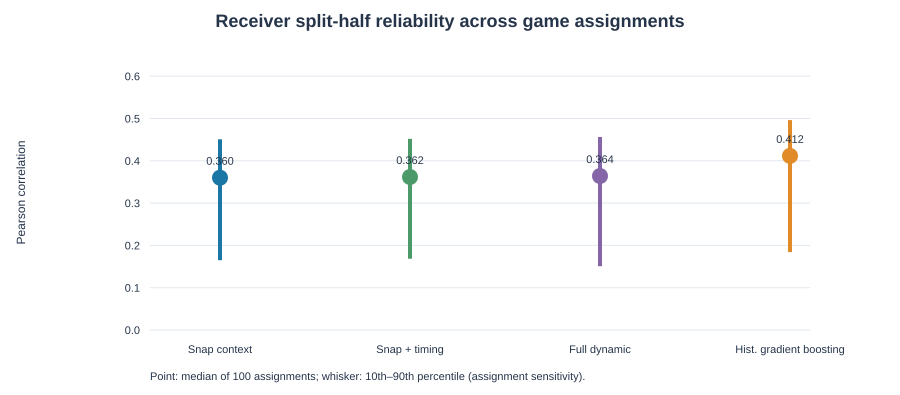

In [1]:
COLORS = {"ridge_snap_context":"#1976a5", "ridge_snap_timing":"#4c9a6a", "ridge_dynamic_context":"#8466a8", "hist_gradient_boosting":"#e08a28"}

def reliability_range_plot(rows):
    selected = [r for r in rows if r["metric"] == "pearson" and r["min_routes_per_half"] == "20"]
    left, right, top, bottom = 150, 810, 55, 330
    ymin, ymax = 0.0, 0.65
    y = lambda v: bottom - (float(v)-ymin)/(ymax-ymin)*(bottom-top)
    parts = ['<svg xmlns="http://www.w3.org/2000/svg" width="900" height="395" viewBox="0 0 900 395"><rect width="100%" height="100%" fill="white"/><style>text{font-family:Arial,sans-serif;fill:#253449}.grid{stroke:#e2e8ee}</style>', '<text x="450" y="27" text-anchor="middle" font-size="18" font-weight="bold">Receiver split-half reliability across game assignments</text>']
    for value in (0,.1,.2,.3,.4,.5,.6):
        yy=y(value); parts += [f'<line class="grid" x1="{left}" y1="{yy:.1f}" x2="{right}" y2="{yy:.1f}"/>',f'<text x="{left-10}" y="{yy+4:.1f}" text-anchor="end" font-size="11">{value:.1f}</text>']
    for i,r in enumerate(selected):
        x=220+i*190; color=COLORS[r["model"]]
        parts += [f'<line x1="{x}" y1="{y(r["p10"]):.1f}" x2="{x}" y2="{y(r["p90"]):.1f}" stroke="{color}" stroke-width="4"/>',f'<circle cx="{x}" cy="{y(r["median"]):.1f}" r="8" fill="{color}"/>',f'<text x="{x}" y="{bottom+23}" text-anchor="middle" font-size="11">{LABELS[r["model"]]}</text>',f'<text x="{x}" y="{y(r["median"])-13:.1f}" text-anchor="middle" font-size="11">{float(r["median"]):.3f}</text>']
    parts += [f'<text x="25" y="{(top+bottom)/2}" text-anchor="middle" font-size="12" transform="rotate(-90 25 {(top+bottom)/2})">Pearson correlation</text>', '<text x="150" y="380" font-size="11">Point: median of 100 assignments; whisker: 10th–90th percentile (assignment sensitivity).</text>', '</svg>']
    return ''.join(parts)

display(SVG(reliability_range_plot(RESULTS["reliability_summary"])))

The boosted model and dynamic Ridge can differ in route-level fit and player-level repeatability. This table isolates repeatability: a better route predictor does not automatically produce a more stable player ranking. Compare the medians and assignment ranges, then inspect the threshold curve below.

In [1]:
def threshold_table(rows):
    body = ""
    for model in LABELS:
        vals = [r for r in rows if r["model"] == model and r["metric"] == "pearson"]
        body += f"<tr><th>{LABELS[model]}</th>" + "".join(f"<td>{float(r['median']):.3f}<small> ({float(r['p10']):.3f}–{float(r['p90']):.3f})</small></td>" for r in vals) + "</tr>"
    headers = "".join(f"<th>{n} routes/half</th>" for n in sorted({r['min_routes_per_half'] for r in rows}, key=int))
    return f"<table><thead><tr><th>Model</th>{headers}</tr></thead><tbody>{body}</tbody></table>"

display(HTML(threshold_table(RESULTS["reliability_summary"])))

Model,10 routes/half,20 routes/half,30 routes/half,40 routes/half,50 routes/half
Snap context,0.250 (0.145–0.355),0.360 (0.165–0.451),0.412 (0.124–0.511),0.300 (0.130–0.576),0.272 (0.131–0.392)
Snap + timing,0.252 (0.147–0.358),0.362 (0.168–0.452),0.413 (0.125–0.514),0.302 (0.135–0.576),0.276 (0.141–0.396)
Full dynamic,0.257 (0.137–0.346),0.364 (0.151–0.456),0.419 (0.133–0.532),0.300 (0.148–0.582),0.296 (0.161–0.399)
Hist. gradient boosting,0.302 (0.197–0.401),0.412 (0.184–0.496),0.466 (0.184–0.574),0.331 (0.192–0.617),0.319 (0.194–0.405)


## Who drives the reference split?

Leave-one-receiver-out recomputes the Pearson correlation after removing each eligible receiver. The table ranks the largest influence in either direction. A large influence identifies sensitivity in a small receiver sample; it is not a reason to discard the player.

In [1]:
def top_influence(rows, n=12):
    rows = sorted(rows, key=lambda r: abs(float(r["change_vs_full"])), reverse=True)[:n]
    body = "".join(f"<tr><td>{LABELS[r['model']]}</td><td>{r['displayName']}</td><td>{float(r['pearson_without_player']):.3f}</td><td>{float(r['change_vs_full']):+.3f}</td></tr>" for r in rows)
    return "<table><thead><tr><th>Model</th><th>Omitted receiver</th><th>Pearson without</th><th>Change</th></tr></thead><tbody>" + body + "</tbody></table>"

display(HTML(top_influence(RESULTS["leave_one_receiver_out"])))

Model,Omitted receiver,Pearson without,Change
Hist. gradient boosting,Rondale Moore,0.223,-0.243
Full dynamic,Rondale Moore,0.222,-0.230
Snap context,Rondale Moore,0.210,-0.220
Snap + timing,Rondale Moore,0.212,-0.219
Snap context,Collin Johnson,0.471,+0.042
Snap + timing,Collin Johnson,0.472,+0.042
Full dynamic,Collin Johnson,0.487,+0.035
Hist. gradient boosting,Ty Montgomery,0.501,+0.035
Hist. gradient boosting,Denzel Mims,0.492,+0.026
Full dynamic,Allen Robinson,0.435,-0.017


## Receiver usage and route-depth residuals

Compare notable high-influence receivers' route counts, shallow-route share, median route depth, starting separation, and alignment. Then inspect calibration by realized route depth and by snap alignment. Persistent residual bias in shallow routes suggests the model's target/context definition deserves attention; it does not imply that shallow routes should be removed.

In [1]:
influential_ids = {r["omitted_receiver"] for r in sorted(RESULTS["leave_one_receiver_out"], key=lambda r: abs(float(r["change_vs_full"])), reverse=True)[:12]}
usage = [r for r in RESULTS["receiver_usage"] if r["nflId"] in influential_ids]
usage = sorted(usage, key=lambda r: float(r["shallow_route_share"]), reverse=True)
body = "".join(f"<tr><td>{r['displayName']}</td><td>{r['routes']}</td><td>{float(r['shallow_route_share']):.1%}</td><td>{float(r['median_route_depth']):.2f}</td><td>{float(r['median_snap_separation']):.2f}</td><td>{r['alignment_mode']}</td></tr>" for r in usage)
display(HTML("<table><thead><tr><th>Receiver</th><th>Routes</th><th>Shallow share (&lt;2 yd)</th><th>Median depth</th><th>Median snap sep.</th><th>Common alignment</th></tr></thead><tbody>" + body + "</tbody></table>"))

Receiver,Routes,Shallow share (<2 yd),Median depth,Median snap sep.,Common alignment
Rondale Moore,97,32.0%,5.10,6.48,SRoWR
Ty Montgomery,70,4.3%,8.54,5.45,RWR
Collin Johnson,88,2.3%,8.31,6.89,LWR
Denzel Mims,60,1.7%,8.45,5.20,RWR
Terrace Marshall,116,0.0%,10.05,5.29,SRWR
Allen Robinson,171,0.0%,7.66,5.68,LWR


### Cross-season influence

The separate 2021-to-2023 evaluation uses only receivers meeting its existing eligibility rule. These leave-one-out changes show whether individual players account for the cross-season residual correlation. The paired line removes Rondale Moore and Isaiah McKenzie together as a sensitivity check; it is not a proposed exclusion from the metric.

In [1]:
cross = RESULTS["cross_season_leave_one_receiver_out"]
focus_names = {"Rondale Moore", "Isaiah McKenzie", "Rondale Moore + Isaiah McKenzie"}
focus = [r for r in cross if r["displayName"] in focus_names]
body = "".join(f"<tr><td>{r['model'].title()}</td><td>{r['displayName']}</td><td>{r['receivers']}</td><td>{float(r['pearson_without_player']):.3f}</td><td>{float(r['change_vs_full']):+.3f}</td></tr>" for r in focus)
display(HTML("<table><thead><tr><th>Model</th><th>Removed receiver(s)</th><th>Remaining</th><th>Cross-season Pearson</th><th>Change</th></tr></thead><tbody>" + body + "</tbody></table>"))

Model,Removed receiver(s),Remaining,Cross-season Pearson,Change
Static,Isaiah McKenzie,90,0.146,-0.229
Static,Rondale Moore,90,0.306,-0.069
Dynamic,Isaiah McKenzie,90,0.235,-0.224
Dynamic,Rondale Moore,90,0.405,-0.054
Static,Rondale Moore + Isaiah McKenzie,89,-0.051,-0.426
Dynamic,Rondale Moore + Isaiah McKenzie,89,0.064,-0.394


In [1]:
depth = [r for r in RESULTS["route_depth_diagnostics"] if not r["route_depth_bin"].startswith("alignment:")]
body = "".join(f"<tr><td>{LABELS[r['model']]}</td><td>{r['route_depth_bin']}</td><td>{r['routes']}</td><td>{float(r['mean_residual']):+.3f}</td><td>{float(r['rmse']):.3f}</td></tr>" for r in depth)
display(HTML("<table><thead><tr><th>Model</th><th>Route depth</th><th>Routes</th><th>Mean residual</th><th>RMSE</th></tr></thead><tbody>" + body + "</tbody></table>"))

Model,Route depth,Routes,Mean residual,RMSE
Snap context,10+ yd,9533,-0.264,1.791
Snap context,2–5 yd,2778,+0.510,1.954
Snap context,5–10 yd,7580,-0.079,1.633
Snap context,<2 yd,524,+3.276,4.805
Snap + timing,10+ yd,9533,-0.252,1.791
Snap + timing,2–5 yd,2778,+0.493,1.952
Snap + timing,5–10 yd,7580,-0.089,1.634
Snap + timing,<2 yd,524,+3.266,4.802
Full dynamic,10+ yd,9533,-0.219,1.750
Full dynamic,2–5 yd,2778,+0.426,1.938


## Interpretation and decision

Residual = observed separation change minus the model's expected change. A positive mean residual means the model underpredicted separation change in that subgroup. We should treat receiver-level reliability as provisional if rankings move substantially across game-half assignments or are dominated by a few players. Route-depth patterns can reveal construct mismatch because the target is snap-to-release nearest-defender distance change, which mixes receiver movement with defender response and defender identity switches.

The next modeling step should depend on these diagnostics: correct a clear context/measurement imbalance first; otherwise proceed to carefully constrained boosted-model tuning and a separate future-season check. Do not add realized route geometry as a predictive feature for this target.

In [1]:
alignment = [r for r in RESULTS["route_depth_diagnostics"] if r["route_depth_bin"].startswith("alignment:")]
display(HTML("<table><thead><tr><th>Model</th><th>Snap alignment</th><th>Routes</th><th>Mean residual</th><th>RMSE</th></tr></thead><tbody>" + "".join(f"<tr><td>{LABELS[r['model']]}</td><td>{r['route_depth_bin'].split(': ',1)[1]}</td><td>{r['routes']}</td><td>{float(r['mean_residual']):+.3f}</td><td>{float(r['rmse']):.3f}</td></tr>" for r in alignment) + "</tbody></table>"))

Model,Snap alignment,Routes,Mean residual,RMSE
Snap context,LWR,6213,-0.000,1.844
Snap context,RWR,6097,-0.001,1.780
Snap context,SLWR,2349,-0.005,2.085
Snap context,HB-R,18,+0.657,3.124
Snap context,SRWR,1938,-0.003,2.058
Snap context,SRoWR,1306,-0.013,1.787
Snap context,SLoWR,1028,-0.009,1.652
Snap context,SLiWR,648,-0.030,2.073
Snap context,SRiWR,714,-0.019,2.222
Snap context,HB-L,17,+1.105,3.544
